# CATSA Random Subject Signal Plot

CATSA 데이터셋에서 무작위 피험자 1명을 선택해,
Baseline / Nback / Stroop / Sudoku 조건에서 ACC, BVP, EDA, HR, TEMP 신호를 시각화합니다.

Selected subject: Sub10


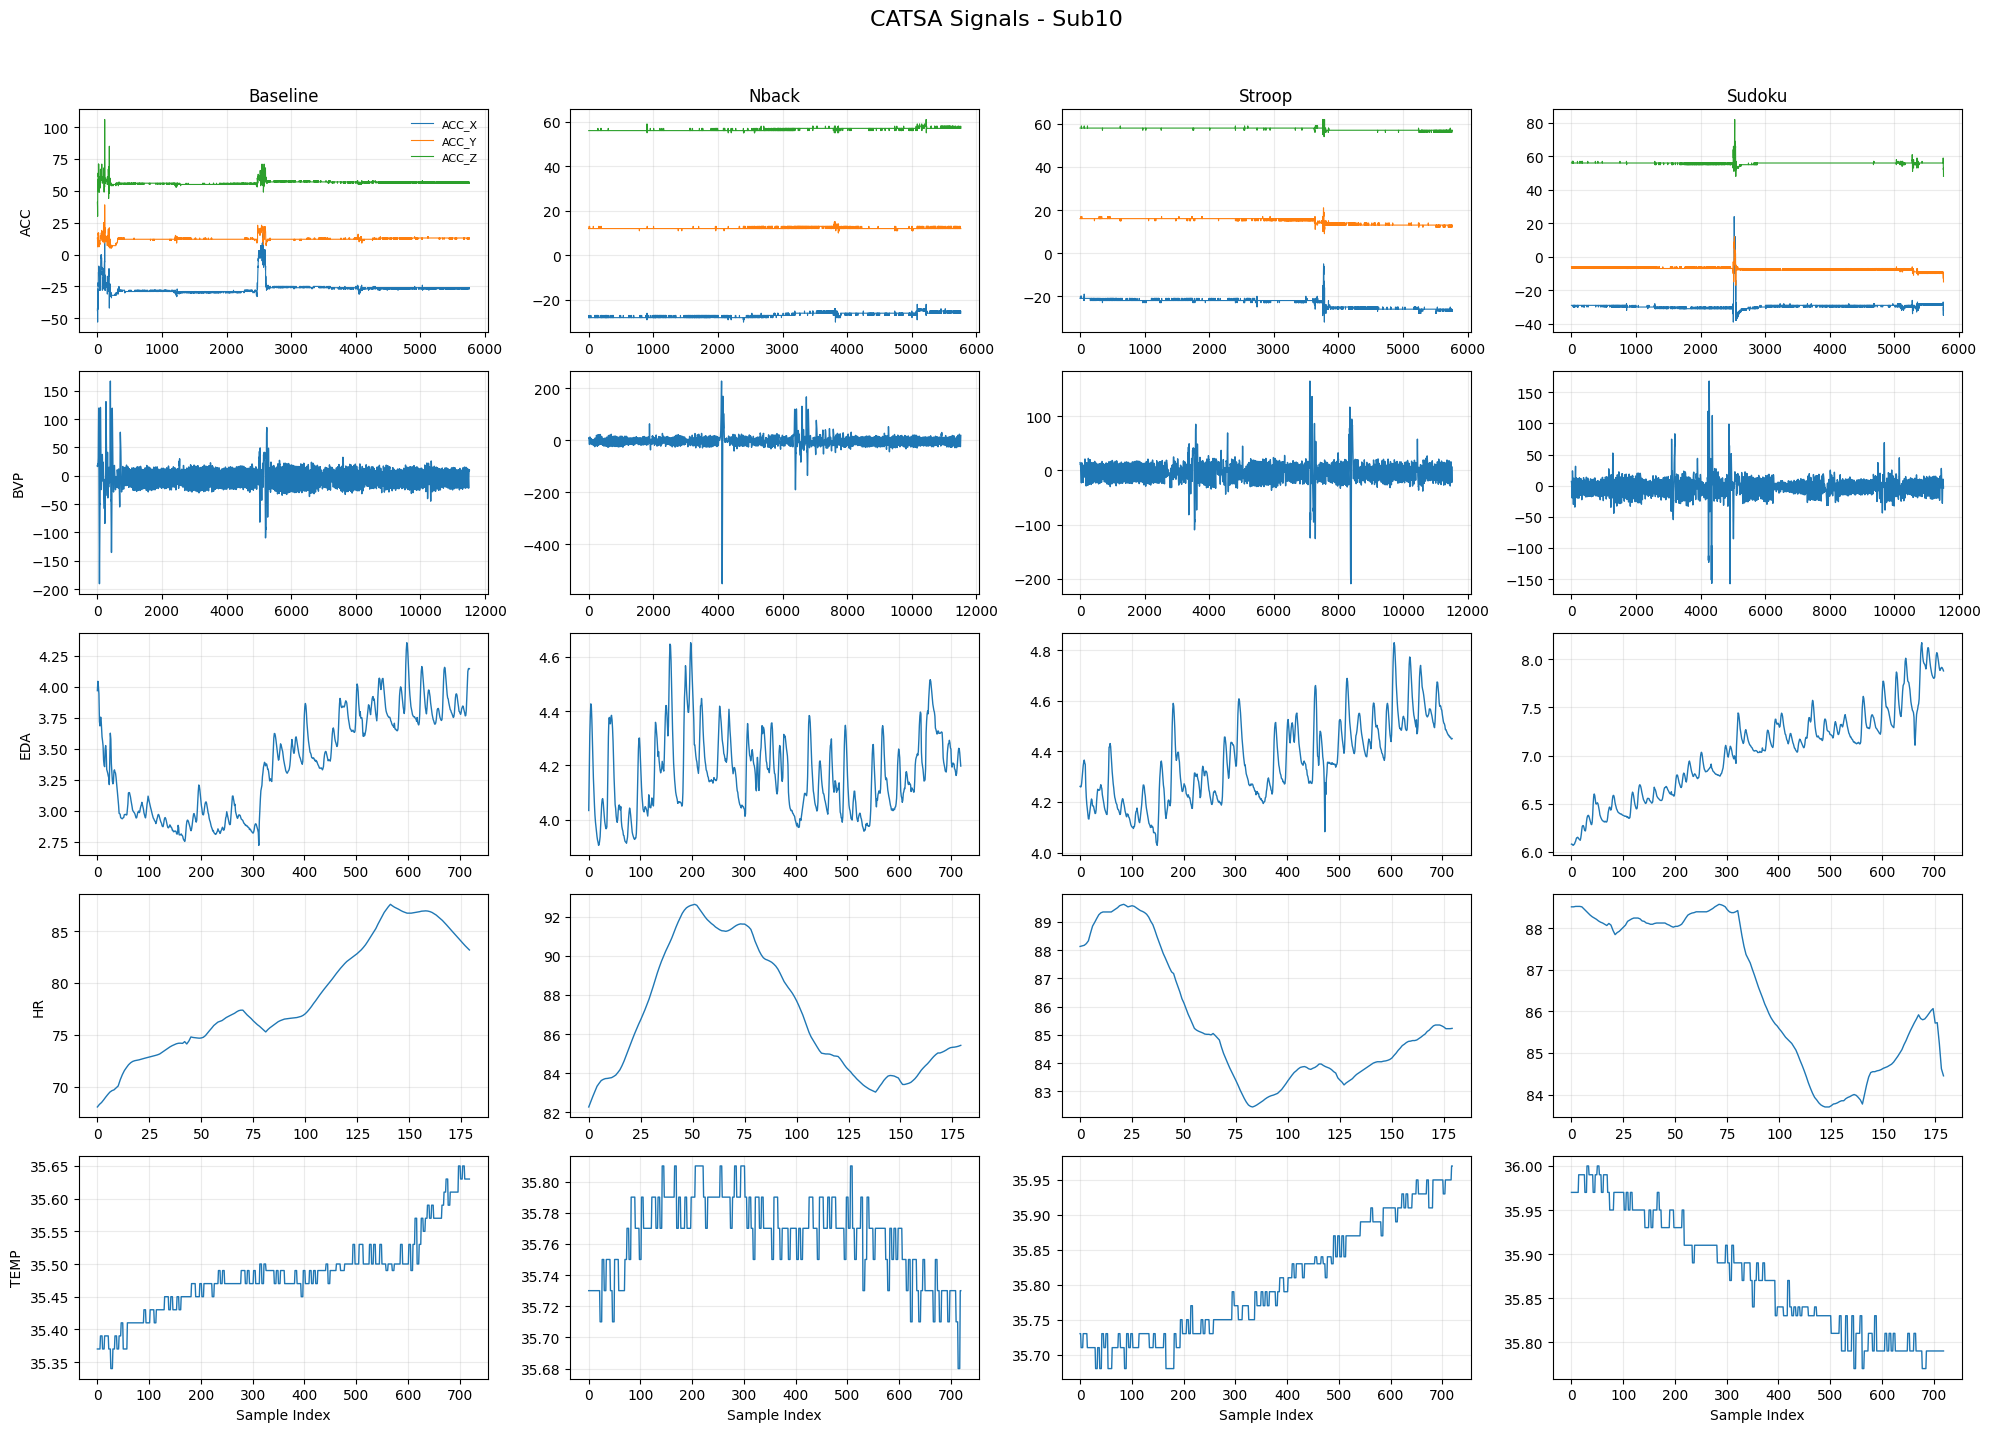

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_ROOT = Path('/home/binghin2/Myproject/Dataset/CATSA')
TASKS = ['Baseline', 'Nback', 'Stroop', 'Sudoku']
SENSORS = ['ACC', 'BVP', 'EDA', 'HR', 'TEMP']

SUBJECT_NUM = 10


def has_required_files(subj_dir: Path) -> bool:
    for task in TASKS:
        task_dir = subj_dir / task
        if not task_dir.exists():
            return False
        for sensor in SENSORS:
            if not (task_dir / f'{sensor}.csv').exists():
                return False
    return True


selected_subject = DATASET_ROOT / f'Sub{SUBJECT_NUM}'
if not selected_subject.exists() or not selected_subject.is_dir():
    raise RuntimeError(f'지정한 피험자 폴더를 찾지 못했습니다: {selected_subject.name}')

if not has_required_files(selected_subject):
    raise RuntimeError(
        f'{selected_subject.name} 폴더에 Baseline/Nback/Stroop/Sudoku 및 ACC/BVP/EDA/HR/TEMP 파일이 완전하지 않습니다.'
    )

print(f'Selected subject: {selected_subject.name}')

fig, axes = plt.subplots(len(SENSORS), len(TASKS), figsize=(20, 14), sharex=False)
fig.suptitle(f'CATSA Signals - {selected_subject.name}', fontsize=16, y=1.02)

for col, task in enumerate(TASKS):
    for row, sensor in enumerate(SENSORS):
        ax = axes[row, col]
        csv_path = selected_subject / task / f'{sensor}.csv'
        df = pd.read_csv(csv_path)

        if sensor == 'ACC':
            # ACC_X, ACC_Y, ACC_Z 3축을 함께 표시
            for c in df.columns:
                ax.plot(df[c].values, linewidth=0.8, label=c)
            if row == 0 and col == 0:
                ax.legend(loc='upper right', fontsize=8, frameon=False)
        else:
            series = df.iloc[:, 0].values
            ax.plot(series, linewidth=1.0, color='#1f77b4')

        if row == 0:
            ax.set_title(task)
        if col == 0:
            ax.set_ylabel(sensor)

        ax.grid(alpha=0.25)

for col in range(len(TASKS)):
    axes[-1, col].set_xlabel('Sample Index')

plt.tight_layout()
plt.show()